L'idée est de tester si la simple représentation sous forme de graphe avec une fonction de coût adaptée fournit les mêmes résultats pour le transport, que ceux obtenus en utilisant les *embeddings*. Cela permet de valider ou pas la pertinence d'une telle approche.

## Imports

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from collections import defaultdict
from poincare import PoincareManifold
from model import Distance_PE
from data_utils import *
from OT_utils import *
from information_content import *
from data import *

Correspondances trouvées : 550


/home/onyxia/work/OT_simulation_maladies/Embeddings/data.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


## Chargement des données

In [2]:
# Avec df_omim et df_orpha issus directement de df_hpoa
omim_to_idx = {v: i for i, v in enumerate(df_omim['database_id'].values)} 
orpha_to_idx = {v: i for i, v in enumerate(df_orpha['database_id'].values)}

ground_truth = []
for _, row in correspondence_exacte.iterrows():
    if row['omim_id'] in omim_to_idx and row['orpha_id'] in orpha_to_idx:
        i = omim_to_idx[row['omim_id']]
        j = orpha_to_idx[row['orpha_id']]
        ground_truth.append((i, j))

df_gt_set = set(ground_truth)

## Fonction de coût

### Pondération par l'*Information Content*

In [6]:
weights, _, _ = compute_information_content(df_omim, G_hpo_work)
weights = {t:1/w for t, w in weights.items()}

In [6]:
def cost_matrix_hamm(df_omim, df_orpha, weights, block_size=256):
    n = df_omim.shape[0]
    m = df_orpha.shape[0]
    C = np.zeros((n, m))

    hpo_cols = [c for c in df_omim.columns if c.startswith('HP:')]
    all_hpo = list(hpo_cols)
    weights_vector = np.array([weights.get(hp, 0.0) for hp in all_hpo])

    omim_matrix = df_omim.reindex(columns=all_hpo, fill_value=0)[all_hpo].values.astype(float)
    orpha_matrix = df_orpha.reindex(columns=all_hpo,  fill_value=0)[all_hpo].values.astype(float)
    
    for i_start in tqdm(range(0, n, block_size)):
        i_end = min(i_start + block_size, n)
        block = omim_matrix[i_start:i_end]
        diff = np.abs(block[:, None, :] - orpha_matrix[None, :, :])
        C[i_start:i_end] = (diff * weights_vector).sum(axis=2)
    return C

In [7]:
C = cost_matrix_hamm(df_omim, df_orpha, weights)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, df_gt_set, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, df_gt_set, C)

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [01:46<00:00, 35.43s/it]

======== Sans régularisation ========
Paires évaluées : 550
Top-1 accuracy : 0.702 (386/550)
Top-3 accuracy : 0.705 (388/550)
Top-5 accuracy : 0.705 (388/550)
 Rang moyen: 76.23
======== Avec régularisation ========
17913.730145857426
Paires évaluées : 550
Top-1 accuracy : 0.693 (381/550)
Top-3 accuracy : 0.825 (454/550)
Top-5 accuracy : 0.853 (469/550)
 Rang moyen: 16.36


### Pondération par la profondeur des noeuds dans le graphe

In [8]:
root = "HP:0000001"
depths = nx.single_source_shortest_path_length(G_hpo_work.reverse(), source=root)

C1 = cost_matrix_hamm(df_omim, df_orpha, depths)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C1, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, df_gt_set, C1)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C1)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C1, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, df_gt_set, C1)

100%|██████████| 3/3 [01:50<00:00, 36.88s/it]


======== Sans régularisation ========
Paires évaluées : 550
Top-1 accuracy : 0.822 (452/550)
Top-3 accuracy : 0.824 (453/550)
Top-5 accuracy : 0.824 (453/550)
 Rang moyen: 49.14
======== Avec régularisation ========
3.8610095206611574
Paires évaluées : 550
Top-1 accuracy : 0.842 (463/550)
Top-3 accuracy : 0.900 (495/550)
Top-5 accuracy : 0.911 (501/550)
 Rang moyen: 5.58


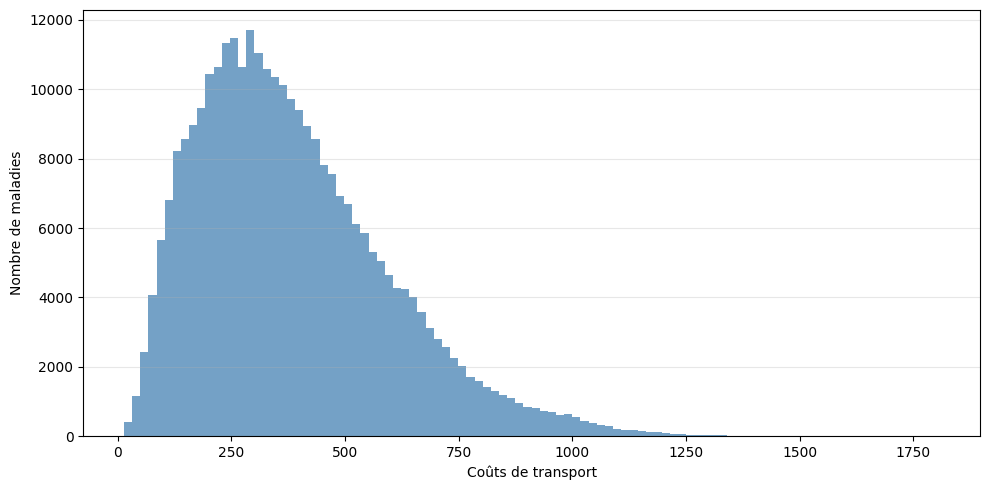

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(C1.ravel(), bins=100, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Coûts de transport")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Etude (rapide) des maladies incorrectement transportées

118/495


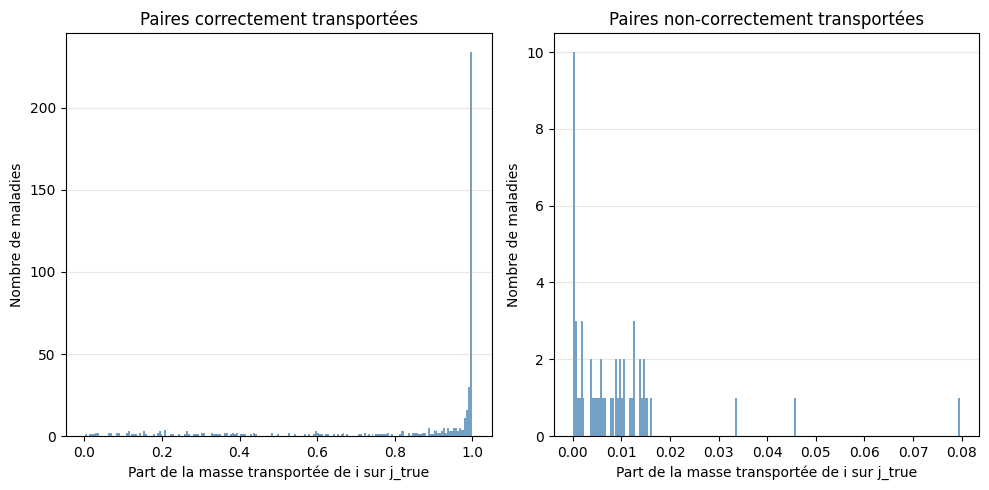

In [ ]:
pairs_zero = [k for k, v in pairs_reg.items() if (v[0] > 3 or v[0]==0)]
correct_pairs = [k for k, v in pairs_reg.items() if (v[0]>=1 and v[0]<=3)]
marginal = np.sum(ot_plan_reg, axis=1)
transported_share = {}
for (i, j_true) in df_gt_set:
    transported_share[(i, j_true)]=ot_plan_reg[i, j_true]/marginal[i]

correct_transported_share = [v for k, v in transported_share.items() if k in correct_pairs]
print(f"{len([v for v in correct_transported_share if v < 0.8])}/{len(correct_transported_share)}")
uncorrect_transported_share = [v for k, v in transported_share.items() if k in pairs_zero]

fig, axes = plt.subplots(1, 2, figsize=(10, 5),)

ax = axes[0]
sns.histplot(correct_transported_share, bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de la masse transportée de i sur j_true")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Paires correctement transportées")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(uncorrect_transported_share, bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de la masse transportée de i sur j_true")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Paires non-correctement transportées")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
dict_ranks_w = {}
for i, k in enumerate(pairs_reg.keys()):
    dict_ranks_w[k]=ranks_reg[i]

pairs_zero_dict = {}
hpo_cols = [c for c in df_omim.columns if c.startswith('HP:')]
idx2omim={t:v for v,t in omim_to_idx.items()}
idx2orpha={t:v for v,t in orpha_to_idx.items()}
for (i,j) in  pairs_zero:
    j_pred = np.argmax(ot_plan_reg[i])
    omim_row = df_omim.iloc[i][hpo_cols]
    orpha_row = df_orpha.iloc[j][hpo_cols]
    orpha_row_pred = df_orpha.iloc[j_pred][hpo_cols]
    
    omim_hpos = omim_row[omim_row == 1].index.tolist()
    orpha_hpos = orpha_row[orpha_row == 1].index.tolist()
    orpha_pred_hpos = orpha_row_pred[orpha_row_pred==1].index.tolist()
    disease_i = pd.unique(df_hpoa[df_hpoa['database_id']==idx2omim[i]]['disease_name'])[0]
    disease_j = pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j]]['disease_name'])[0]

    pairs_zero_dict[(i, j)] = {
        "rank": dict_ranks_w[(i,j)],
        "omim":  {"name": disease_i, "count": len(omim_hpos), "terms": omim_hpos},
        "orpha": {"name": disease_j, "count": len(orpha_hpos), "terms": orpha_hpos},
        "commun":set(omim_hpos)&set(orpha_hpos),
        "cost_true": C1[i, j],
        "cost_pred": C1[i, j_pred],
        "predicted_disease" : pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j_pred]]['disease_name'])[0],
        "count_pred" : len(orpha_pred_hpos),
        "terms pred" : orpha_pred_hpos
    }

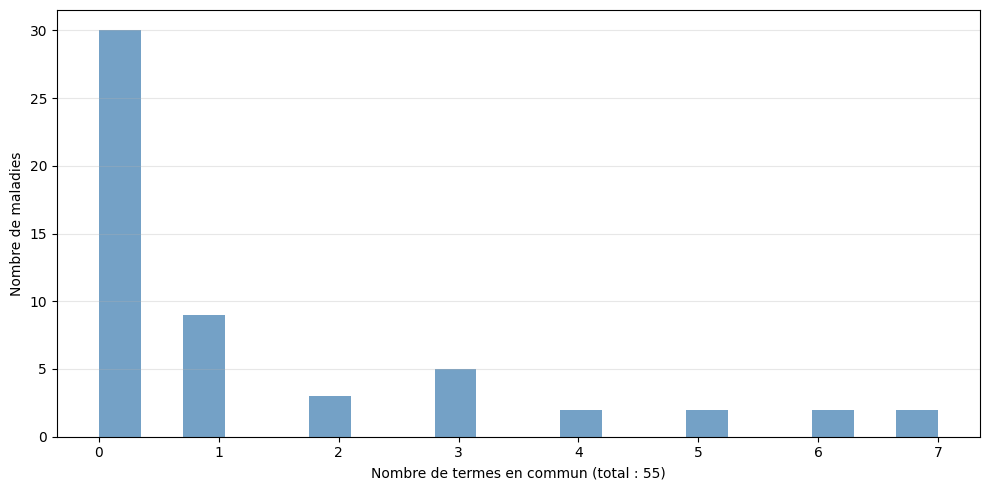

In [11]:
# Termes HP en commun parmi les maladies non associées
communs_w = np.array([len(v['commun'])  for v in pairs_zero_dict.values()])

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(communs_w, bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel(f"Nombre de termes en commun (total : {len(communs_w)})")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

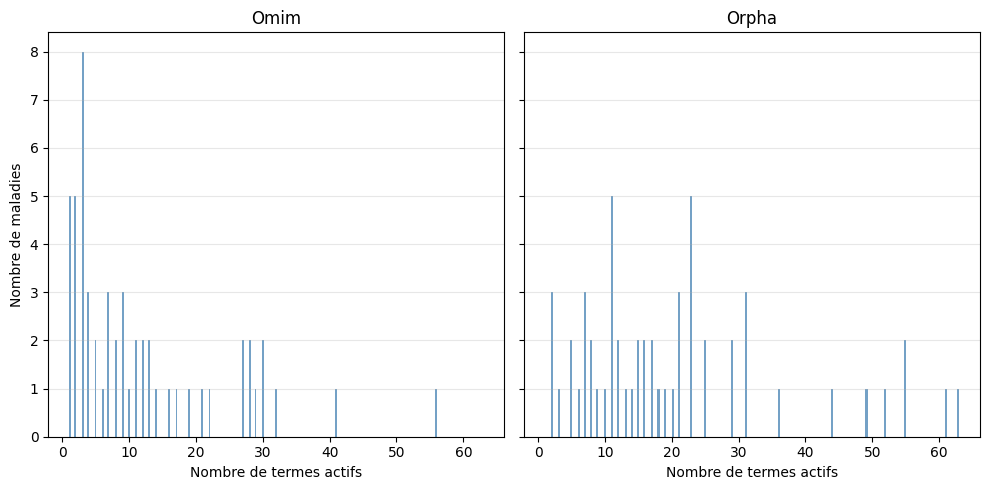

In [12]:
# Nombre de termes omim dans les maladies que l'on ne retrouve pas
omim_counts = np.array([v['omim']['count']  for v in pairs_zero_dict.values()])
orpha_counts = np.array([v['orpha']['count'] for v in pairs_zero_dict.values()])


fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax = axes[0]
sns.histplot(omim_counts, bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Omim")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(orpha_counts, bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Orpha")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
df = pd.read_csv("../data/utils/paires_zero_wass.csv")

paires_zero_dict_wass = {}
for _, row in df.iterrows():
    key = (row["i"], row["j"])
    paires_zero_dict_wass[key] = {
        "rank": row["rank"],
        "omim": {
            "name": row["omim_name"],
            "count": row["omim_count"],
            "terms": row["omim_terms"].split("|")
        },
        "orpha": {
            "name": row["orpha_name"],
            "count": row["orpha_count"],
            "terms": row["orpha_terms"].split("|")
        },
        "commun": set(row["commun"].split("|")) if pd.notna(row["commun"]) else set(),
        "cost_true": row["cost_true"],
        "cost_pred": row["cost_pred"],
        "terms_pred": row["terms_pred"]
    }

In [30]:
print("Maladies mal associées dans les deux cas :", len(set(paires_zero_dict_wass.keys())& set(pairs_zero_dict.keys())))
print(len(paires_zero_dict_wass.keys()))
print(len(pairs_zero_dict.keys()))

inter = set(paires_zero_dict_wass.keys()) & set(pairs_zero_dict.keys())
comp = {k:v for k, v in pairs_zero_dict.items() if k not in inter}
intersect = {k:v for k,v in pairs_zero_dict.items() if k in inter}
print(np.median(sorted([intersect[k]["rank"] for k in intersect.keys()])))
print(np.median(sorted([comp[k]["rank"] for k in comp.keys()])))

Maladies mal associées dans les deux cas : 25
46
55
32.0
15.0


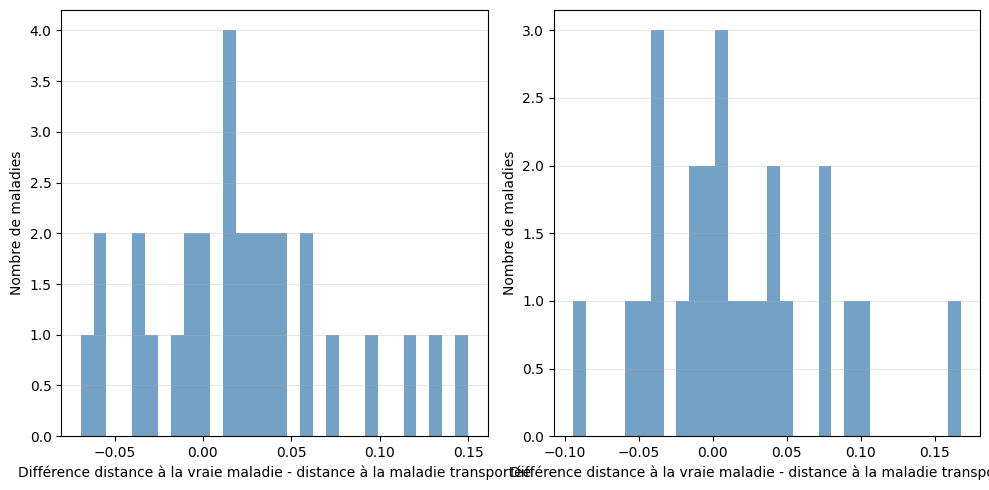

In [37]:
cost_gap_comp = [(comp[k]["cost_true"]-comp[k]["cost_pred"])/(np.max(C1.ravel())-np.min(C1.ravel())) for k in comp.keys()]
cost_gap_inter = [(intersect[k]["cost_true"]-intersect[k]["cost_pred"])/(np.max(C1.ravel())-np.min(C1.ravel())) for k in intersect.keys()]

fig, axes = plt.subplots(1, 2, figsize=(10, 5),)

ax = axes[0]

sns.histplot(cost_gap_comp, bins=30, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Différence distance à la vraie maladie - distance à la maladie transportée")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(cost_gap_inter, bins=30, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Différence distance à la vraie maladie - distance à la maladie transportée")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Distances de Jaccard, $l_2$, Hamming non pondérées

In [12]:
# Distance euclidienne
C = basic_cost_matrix(df_omim, df_orpha, 'euclidean')

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, df_gt_set, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, df_gt_set, C)

Check : (550, 550)
======== Sans régularisation ========
Paires évaluées : 550
Top-1 accuracy : 0.760 (418/550)
Top-3 accuracy : 0.762 (419/550)
Top-5 accuracy : 0.762 (419/550)
 Rang moyen: 64.54
======== Avec régularisation ========
0.07462939636320927
Paires évaluées : 550
Top-1 accuracy : 0.778 (428/550)
Top-3 accuracy : 0.838 (461/550)
Top-5 accuracy : 0.849 (467/550)
 Rang moyen: 13.56


In [13]:
# Distance Jaccard
C = basic_cost_matrix(df_omim, df_orpha, 'jaccard')

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, df_gt_set, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, df_gt_set, C)

Check : (550, 550)
======== Sans régularisation ========
Paires évaluées : 550
Top-1 accuracy : 0.804 (442/550)
Top-3 accuracy : 0.805 (443/550)
Top-5 accuracy : 0.805 (443/550)
 Rang moyen: 50.95
======== Avec régularisation ========
0.009850633357655946
Paires évaluées : 550
Top-1 accuracy : 0.822 (452/550)
Top-3 accuracy : 0.902 (496/550)
Top-5 accuracy : 0.916 (504/550)
 Rang moyen: 5.96


In [15]:
# Distance Hamming
C = basic_cost_matrix(df_omim, df_orpha, 'hamming')

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, df_gt_set, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, df_gt_set, C)

Check : (550, 550)
======== Sans régularisation ========
Paires évaluées : 550
Top-1 accuracy : 0.829 (456/550)
Top-3 accuracy : 0.831 (457/550)
Top-5 accuracy : 0.831 (457/550)
 Rang moyen: 47.36
======== Avec régularisation ========
5.143756676224209e-05
Paires évaluées : 550
Top-1 accuracy : 0.835 (459/550)
Top-3 accuracy : 0.904 (497/550)
Top-5 accuracy : 0.913 (502/550)
 Rang moyen: 5.83


Nombres de maladies correctement transportées, mais à moins de 80% de masse : 116/497


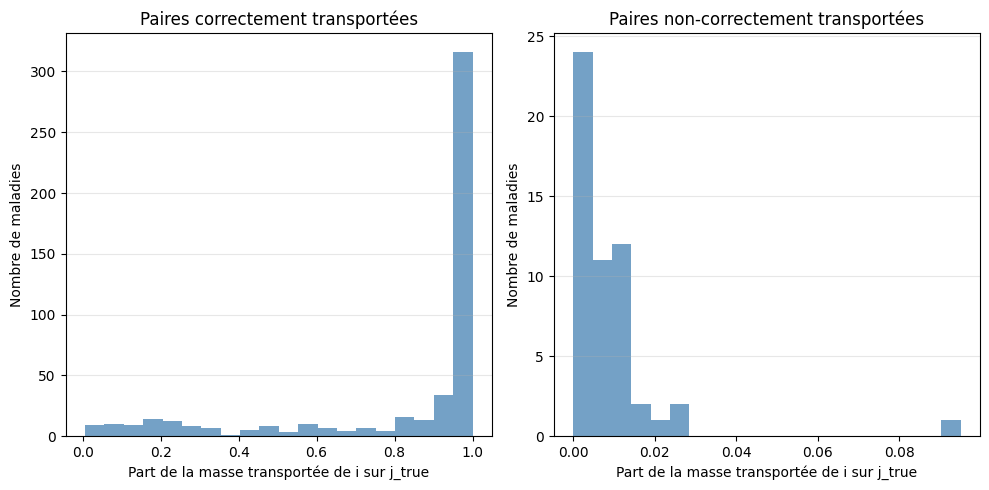

In [18]:
pairs_zero = [k for k, v in pairs_reg.items() if (v[0] > 3 or v[0]==0)]
correct_pairs = [k for k, v in pairs_reg.items() if (v[0]>=1 and v[0]<=3)]
marginal = np.sum(ot_plan_reg, axis=1)
transported_share = {}
for (i, j_true) in df_gt_set:
    transported_share[(i, j_true)]=ot_plan_reg[i, j_true]/marginal[i]

correct_transported_share = [v for k, v in transported_share.items() if k in correct_pairs]
print(f"Nombres de maladies correctement transportées, mais à moins de 80% de masse : {len([v for v in correct_transported_share if v < 0.8])}/{len(correct_transported_share)}")
uncorrect_transported_share = [v for k, v in transported_share.items() if k in pairs_zero]

fig, axes = plt.subplots(1, 2, figsize=(10, 5),)

ax = axes[0]
sns.histplot(correct_transported_share, bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de la masse transportée de i sur j_true")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Paires correctement transportées")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(uncorrect_transported_share, bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de la masse transportée de i sur j_true")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Paires non-correctement transportées")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

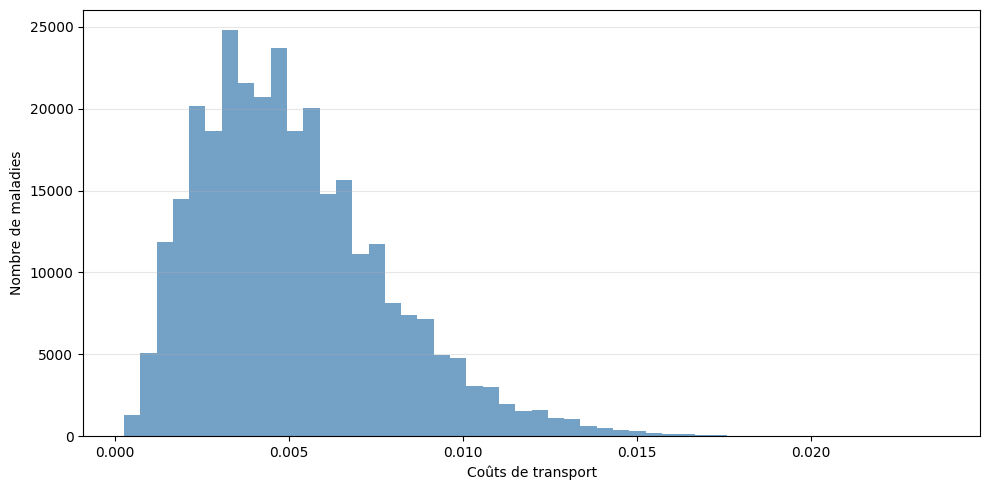

In [23]:
# Distribution du coût de transport
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(C.ravel(), bins=50, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Coûts de transport")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
np.var(C, axis=1)/np.mean(C, axis=1)

array([0.00085887, 0.00051003, 0.00026571, 0.00045399, 0.00063361,
       0.00069262, 0.00079886, 0.0003585 , 0.00124864, 0.00094767,
       0.00071375, 0.0012857 , 0.00046337, 0.00121572, 0.00117418,
       0.0011455 , 0.00092635, 0.0010599 , 0.00095004, 0.00096188,
       0.00121407, 0.00094507, 0.00108183, 0.00024496, 0.00051035,
       0.00073259, 0.00024627, 0.00044272, 0.00081626, 0.00127407,
       0.00041166, 0.00117829, 0.00121146, 0.00109484, 0.00074802,
       0.00113017, 0.00095781, 0.00039664, 0.00089177, 0.00061327,
       0.0008659 , 0.00111365, 0.00124997, 0.00128653, 0.0009973 ,
       0.00128604, 0.00062335, 0.00037936, 0.00066482, 0.00097346,
       0.00120808, 0.00121599, 0.00037075, 0.00071111, 0.00098611,
       0.0011481 , 0.00033835, 0.00077924, 0.00104096, 0.00112019,
       0.00109478, 0.00064229, 0.00113683, 0.00093378, 0.00023558,
       0.00120768, 0.00095289, 0.00104041, 0.00028881, 0.0009271 ,
       0.00125056, 0.0007934 , 0.000326  , 0.00105833, 0.00061

## Utilisation de la table de correspondances d'Orphadata

In [3]:
def f_ground_truth(work_omim, work_orpha, df_orpha_omim):
    omim_to_idx = {v: i for i, v in enumerate(work_omim['database_id'].values)} 
    orpha_to_idx = {v: i for i, v in enumerate(work_orpha['database_id'].values)}

    ground_truth = []
    valid_omim = []
    valid_orpha = []
    for _, row in df_orpha_omim.iterrows():
        if row['omim_id'] in omim_to_idx and row['orpha_id'] in orpha_to_idx:
            i = omim_to_idx[row['omim_id']]
            j = orpha_to_idx[row['orpha_id']]
            ground_truth.append((i, j))
            valid_omim.append(row['omim_id'])
            valid_orpha.append(row['orpha_id'])
    gt_set = set(ground_truth)
    return gt_set, valid_omim, valid_orpha
gt_set, valid_omim, valid_orpha = f_ground_truth(work_omim, work_orpha, df_orpha_omim)

In [24]:
work_omim0 = work_omim[work_omim['database_id'].isin(valid_omim)]
work_orpha0 = work_orpha[work_orpha['database_id'].isin(valid_orpha)]
hpo_cols0 = [c for c in work_omim0.columns if c.startswith("HP:")]
print(work_omim0.shape, work_orpha0.shape)

omim_to_idx0  = {v: i for i, v in enumerate(work_omim0['database_id'].values)}
orpha_to_idx0 = {v: i for i, v in enumerate(work_orpha0['database_id'].values)}

# 3. Reconstruire ground_truth avec les nouveaux indices
ground_truth = []
for _, row in df_orpha_omim.iterrows():
    if row['omim_id'] in omim_to_idx0 and row['orpha_id'] in orpha_to_idx0:
        i = omim_to_idx0[row['omim_id']]
        j = orpha_to_idx0[row['orpha_id']]
        ground_truth.append((i, j))

gt_set = set(ground_truth)

print(f"Taille OMIM : {work_omim0.shape[0]}, ORPHA : {work_orpha0.shape[0]}, paires GT : {len(gt_set)}")

(4688, 11614) (2971, 11614)
Taille OMIM : 4688, ORPHA : 2971, paires GT : 5312


### Distances simples $l_2$, Jaccard, Hamming

In [ ]:
# Dictionnaire pour stocker les résultats méthode par méthode
dict_method={}

# Distances de base
for dist_method in ['euclidean', 'jaccard', 'hamming']:
    print(dist_method)
    C = basic_cost_matrix(work_omim0, work_orpha0, dist_method)

    # Sans régularisation
    print("======== Sans régularisation ========")
    ot_plan, ot_cost = compute_transport(C, a=None, b=None)
    ranks, pairs = evaluate_transport(ot_plan, gt_set, C)

    # Avec régularisation
    print("======== Avec régularisation ========")
    grid = np.linspace(0.01, 5, 100)
    epsilon = grid[2] * np.mean(C)
    print(epsilon)
    ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
    ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gt_set, C)
    print("")
    dict_method[f"{dist_method} reg"] = {"ranks": ranks_reg,
                                         "pairs": pairs_reg,
                                         "ot_plan": ot_plan_reg,
                                         "cost_matrix": C}

euclidean
Check : (4688, 2971)
======== Sans régularisation ========
Paires évaluées : 5312
Top-1 accuracy : 0.342 (1816/5312)
Top-3 accuracy : 0.380 (2020/5312)
Top-5 accuracy : 0.381 (2026/5312)
 Rang moyen: 953.10
======== Avec régularisation ========
0.7418450988280834
Paires évaluées : 5312
Top-1 accuracy : 0.357 (1894/5312)
Top-3 accuracy : 0.495 (2632/5312)
Top-5 accuracy : 0.555 (2946/5312)
 Rang moyen: 198.83

jaccard


/opt/python/lib/python3.13/site-packages/sklearn/metrics/pairwise.py:2474: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Check : (4688, 2971)
======== Sans régularisation ========
Paires évaluées : 5312
Top-1 accuracy : 0.358 (1901/5312)
Top-3 accuracy : 0.406 (2157/5312)
Top-5 accuracy : 0.408 (2165/5312)
 Rang moyen: 913.58
======== Avec régularisation ========
0.10964876203341832
Paires évaluées : 5312
Top-1 accuracy : 0.359 (1906/5312)
Top-3 accuracy : 0.519 (2756/5312)
Top-5 accuracy : 0.590 (3133/5312)
 Rang moyen: 93.62

hamming
Check : (4688, 2971)
======== Sans régularisation ========
Paires évaluées : 5312
Top-1 accuracy : 0.349 (1856/5312)
Top-3 accuracy : 0.402 (2135/5312)
Top-5 accuracy : 0.403 (2143/5312)
 Rang moyen: 919.16
======== Avec régularisation ========
0.0004595834570932588
Paires évaluées : 5312
Top-1 accuracy : 0.399 (2118/5312)
Top-3 accuracy : 0.550 (2922/5312)
Top-5 accuracy : 0.613 (3256/5312)
 Rang moyen: 105.41



### Distances pondérées en exploitant juste la structure d'arbre 

In [7]:
root = "HP:0000001"
depths = nx.single_source_shortest_path_length(G_hpo_work.reverse(), source=root)

C1 = cost_matrix_hamm(work_omim0, work_orpha0, depths)
print(np.isnan(C1).sum(), np.isinf(C).sum())

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C1, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, gt_set, C1)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C1)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C1, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gt_set, C1)
dict_method["profondeur reg"]={"ranks": ranks_reg,
                        "pairs": pairs_reg,
                        "ot_plan": ot_plan_reg,
                        "cost_matrix": C1}

0 0
======== Sans régularisation ========
Paires évaluées : 5312
Top-1 accuracy : 0.353 (1876/5312)
Top-3 accuracy : 0.403 (2141/5312)
Top-5 accuracy : 0.404 (2147/5312)
 Rang moyen: 921.16
======== Avec régularisation ========
18.437434050030316
Paires évaluées : 5312
Top-1 accuracy : 0.404 (2144/5312)
Top-3 accuracy : 0.545 (2897/5312)
Top-5 accuracy : 0.607 (3225/5312)
 Rang moyen: 126.63


In [8]:
weights, _, _ = compute_information_content(work_omim0, G_hpo_work)
weights = {t:-np.log(w) for t, w in weights.items()}

C1 = cost_matrix_hamm(work_omim0, work_orpha0, weights)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C1, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, gt_set, C1)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[2] * np.mean(C1)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C1, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gt_set, C1)
dict_method["ic"]={"ranks": ranks_reg,
                    "pairs": pairs_reg,
                    "ot_plan": ot_plan_reg,
                    "cost_matrix": C1}

======== Sans régularisation ========
Paires évaluées : 5312
Top-1 accuracy : 0.364 (1931/5312)
Top-3 accuracy : 0.415 (2203/5312)
Top-5 accuracy : 0.416 (2211/5312)
 Rang moyen: 902.03
======== Avec régularisation ========
49.85082929940785
Paires évaluées : 5312
Top-1 accuracy : 0.411 (2184/5312)
Top-3 accuracy : 0.569 (3020/5312)
Top-5 accuracy : 0.627 (3328/5312)
 Rang moyen: 98.19


In [16]:
not_min=defaultdict(set)
for (i, j_true) in gt_set:
    j_pred = np.argmin(C1[i])
    if j_pred != j_true:
        not_min[(i,j_true)].add(j_pred)
        # print(f"C[i, j_true]={C1[i,j_true]:.3f}, C[i, j_pred]={C1[i,j_pred]:.3f}")
print(f"{len(not_min)}/{len(gt_set)} soit {np.round(len(not_min)/len(gt_set), 2)*100}%")

4800/5312 soit 90.0%


### Distances qui exploitent l'*embedding*

In [9]:
checkpoint = torch.load('logs/2026_5_7/12/model_final.pt', map_location='cpu', weights_only=False)
hp = checkpoint['hyperparams']
objects = checkpoint['objects']
manifold = PoincareManifold()
model = Distance_PE(n=len(objects), dim=hp['dim'],
                       manifold=manifold, sparse=False, learn_curvature=False, init_curvature=1., weight_decay=0)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()


Distance_PE(
  (embeddings): Embedding(19389, 15)
)

In [10]:
C_jacc = compute_cost_matrix_pseudo_jacc(work_omim0, work_orpha0, node2id_w, model)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C_jacc, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, gt_set, C_jacc)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[2] * np.mean(C_jacc)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C_jacc, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gt_set, C_jacc)
dict_method["embedding_hamming"]={"ranks": ranks_reg,
                    "pairs": pairs_reg,
                    "ot_plan": ot_plan_reg,
                    "cost_matrix": C_jacc}

Compute norms
Norms computed !
C[0,0]  ref=198.891600  new=198.891600  diff=2.84e-14
C[3,7]  ref=242.355649  new=242.355649  diff=2.84e-14
C[9,14]  ref=85.874428  new=85.874428  diff=0.00e+00
======== Sans régularisation ========
Paires évaluées : 5312
Top-1 accuracy : 0.352 (1871/5312)
Top-3 accuracy : 0.404 (2147/5312)
Top-5 accuracy : 0.406 (2158/5312)
 Rang moyen: 917.12
======== Avec régularisation ========
21.536439608452998
Paires évaluées : 5312
Top-1 accuracy : 0.399 (2118/5312)
Top-3 accuracy : 0.547 (2904/5312)
Top-5 accuracy : 0.607 (3226/5312)
 Rang moyen: 105.44


In [11]:
C_wass = compute_costs_matrix_wasserstein2(work_omim0, work_orpha0, node2id_w, model, deprecated)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C_wass, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, gt_set, C_wass)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_wass)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C_wass, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gt_set, C_wass)
dict_method["embedding_wasserstein"]={"ranks": ranks_reg,
                    "pairs": pairs_reg,
                    "ot_plan": ot_plan_reg,
                    "cost_matrix": C_wass}

Precompute...
Finished !
Precomputing full HPO distance matrix...
HPO distance matrix: (10042, 10042)


OMIM:   0%|          | 0/4688 [00:00<?, ?it/s]/home/onyxia/work/OT_simulation_maladies/Embeddings/OT_utils.py:386: SyntaxWarning: invalid escape sequence '\e'
  ax[0].set_ylabel('$||P^* - P_\epsilon^*||_F$', fontsize=25)
/home/onyxia/work/OT_simulation_maladies/Embeddings/OT_utils.py:390: SyntaxWarning: invalid escape sequence '\e'
  ax[1].set_xlabel('Regularization Strength $\epsilon$', fontsize=25)
OMIM: 100%|██████████| 4688/4688 [15:18<00:00,  5.10it/s]


======== Sans régularisation ========
Paires évaluées : 5312
Top-1 accuracy : 0.296 (1571/5312)
Top-3 accuracy : 0.346 (1840/5312)
Top-5 accuracy : 0.347 (1845/5312)
 Rang moyen: 1004.65
======== Avec régularisation ========
0.07212071515454727
Paires évaluées : 5312
Top-1 accuracy : 0.325 (1724/5312)
Top-3 accuracy : 0.462 (2454/5312)
Top-5 accuracy : 0.523 (2777/5312)
 Rang moyen: 116.45


In [14]:
# Distance dans C entre la vraie paire vs le meilleur match trouvé
not_min=defaultdict(set)
for (i, j_true) in gt_set:
    j_pred = np.argmin(C_wass[i])
    if j_pred != j_true:
        not_min[(i,j_true)].add(j_pred)
        # print(f"C[i, j_true]={C_wass[i,j_true]:.3f}, C[i, j_pred]={C_wass[i,j_pred]:.3f}")
print(f"{len(not_min)}/{len(gt_set)} soit {np.round(len(not_min)/len(gt_set), 2)*100}%")

3663/5312 soit 69.0%


### Distance s'appuyant sur la similarité de Resnik

In [4]:
# Calcul de l'IC de chaque terme HPO
print("Compute information content...")
ic, _, _ = compute_information_content(work_omim0, G_hpo_work)
ic = {t:-np.log(w) for t, w in ic.items()}

# Calcul de la similarité entre chaque paire de termes HPO
print("Compute similarities...")
hpo_sim = resnik_similarity(work_omim0, G_hpo_work, ic)

Compute information content...
Compute similarities...
Precomputing ancestors...
Finished !


11613it [01:44, 111.52it/s]


In [7]:
def resnik_disease_similarities(df_omim, df_orpha, resnik_hpos, method):
    n = df_omim.shape[0]
    m = df_orpha.shape[0]

    colnames = [c for c in df_omim.columns if c.startswith('HP:')]
    X = df_omim[colnames].values
    Y = df_orpha[colnames].values
    M = np.exp(-resnik_hpos) 
    if method == 'sum':
        C = X @ M @ Y.T
    if method =='max':
        C = np.zeros((n, m))
        for i in tqdm(range(n)):
            active_i = np.where(X[i] == 1)[0]   # termes actifs de la maladie i
            if len(active_i) == 0:
                continue
            for j in range(m):
                active_j = np.where(Y[j] == 1)[0]  # termes actifs de la maladie j
                if len(active_j) == 0:
                    continue
                C[i, j] = M[np.ix_(active_i, active_j)].min()
    return C

In [8]:
C = resnik_disease_similarities(work_omim0, work_orpha0, hpo_sim, 'max')

100%|██████████| 4688/4688 [06:16<00:00, 12.47it/s]


In [15]:
ot_plan, ot_cost = compute_transport(C, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, gt_set, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C)
print(epsilon)
for eps in [1e-5, 0.001,0.01, 0.1, 1.]:
    ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, eps, 100000, 1e-4, False)
    ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gt_set, C)

Paires évaluées : 5312
Top-1 accuracy : 0.110 (585/5312)
Top-3 accuracy : 0.147 (779/5312)
Top-5 accuracy : 0.147 (782/5312)
 Rang moyen: 1309.57
======== Avec régularisation ========
0.0001338570118916921


/opt/python/lib/python3.13/site-packages/ot/bregman/_sinkhorn.py:631: RuntimeWarning: divide by zero encountered in divide
  u = 1.0 / nx.dot(Kp, v)
/opt/python/lib/python3.13/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/home/onyxia/work/OT_simulation_maladies/Embeddings/OT_utils.py:365: RuntimeWarning: invalid value encountered in scalar divide
  pairs[(i, j_true)]=[0, C[i, j_true], P[i, j_true]/marginal[i]]


Paires évaluées : 5312
Top-1 accuracy : 0.106 (562/5312)
Top-3 accuracy : 0.233 (1237/5312)
Top-5 accuracy : 0.307 (1632/5312)
 Rang moyen: 87.49
Paires évaluées : 5312
Top-1 accuracy : 0.018 (98/5312)
Top-3 accuracy : 0.042 (224/5312)
Top-5 accuracy : 0.062 (328/5312)
 Rang moyen: 476.92
Paires évaluées : 5312
Top-1 accuracy : 0.006 (32/5312)
Top-3 accuracy : 0.016 (83/5312)
Top-5 accuracy : 0.025 (135/5312)
 Rang moyen: 923.58
Paires évaluées : 5312
Top-1 accuracy : 0.004 (22/5312)
Top-3 accuracy : 0.008 (43/5312)
Top-5 accuracy : 0.015 (78/5312)
 Rang moyen: 1152.91
Paires évaluées : 5312
Top-1 accuracy : 0.004 (23/5312)
Top-3 accuracy : 0.008 (45/5312)
Top-5 accuracy : 0.016 (86/5312)
 Rang moyen: 1171.90


## Comparaison des résultats des différentes méthodes

In [5]:
import pickle

# Sauvegarde du dictionnaire
#with open("../data/utils/dict_method.pickle", 'wb') as file:
    #pickle.dump(dict_method, file)
with open("../data/utils/dict_method.pickle", 'rb') as file:
    dict_method = pickle.load(file)

inter = np.zeros((len(dict_method.keys()), len(dict_method.keys())))
inter_null = np.zeros((len(dict_method.keys()), len(dict_method.keys())))
overall_correct = gt_set
overall_incorrect = gt_set
cost_corr = np.zeros((len(dict_method), len(dict_method)))
for i, method1 in enumerate(dict_method.keys()):
    C1 = dict_method[method1]["cost_matrix"].flatten()

    pairsi = dict_method[method1]["pairs"]
    correct_pairsi = [k for k, v in pairsi.items() if (v[0] <= 3 and v[0]!=0)]
    pairs0i = [k for k, v in pairsi.items() if (v[0] > 3 or v[0]==0)]
    overall_correct = overall_correct & set(correct_pairsi)
    overall_incorrect = overall_incorrect & set(pairs0i)
    for j, method2 in enumerate(dict_method.keys()):
        C2 = dict_method[method2]["cost_matrix"].flatten()
        cost_corr[i, j]=np.corrcoef(C1, C2)[0,1]

        pairsj = dict_method[method2]["pairs"]
        correct_pairsj = [k for k, v in pairsj.items() if (v[0] <= 3 and v[0]!=0)]
        pairs0j = [k for k, v in pairsj.items() if (v[0] > 3 or v[0]==0)]
        inter[i, j] = np.round(len(set(correct_pairsi)&set(correct_pairsj))/len(correct_pairsi)*100, 0)
        inter_null[i, j] = np.round(len((set(pairs0i)&set(pairs0j)))/len(pairs0i)*100, 0)

# Corrélation entre les matrices de coûts
print(dict_method.keys())
print(cost_corr)
print("")

# Paires communes correctement ou incorrectement transportées
print(dict_method.keys())
print("Paires correctement transportées en commun")
print(inter)
print("Paires incorrectement transportées en commun")
print(inter_null)
print("Check : ", overall_correct&overall_incorrect)

dict_keys(['euclidean reg', 'jaccard reg', 'hamming reg', 'profondeur reg', 'ic', 'embedding_hamming', 'embedding_wasserstein'])
[[ 1.         -0.23573931  0.98340623  0.97445213  0.97793662  0.9822081
  -0.58665391]
 [-0.23573931  1.         -0.23534008 -0.24562533 -0.22264255 -0.23226233
   0.54674597]
 [ 0.98340623 -0.23534008  1.          0.99351316  0.99591069  0.99827339
  -0.55465102]
 [ 0.97445213 -0.24562533  0.99351316  1.          0.98907717  0.99085888
  -0.54871366]
 [ 0.97793662 -0.22264255  0.99591069  0.98907717  1.          0.99640848
  -0.54271201]
 [ 0.9822081  -0.23226233  0.99827339  0.99085888  0.99640848  1.
  -0.55111101]
 [-0.58665391  0.54674597 -0.55465102 -0.54871366 -0.54271201 -0.55111101
   1.        ]]

dict_keys(['euclidean reg', 'jaccard reg', 'hamming reg', 'profondeur reg', 'ic', 'embedding_hamming', 'embedding_wasserstein'])
Paires correctement transportées en commun
[[100.  92.  93.  91.  93.  93.  76.]
 [ 88. 100.  88.  89.  90.  88.  74.]
 [ 84. 

Les matrices de coûts sont très corrélées entre elles (à l'exception d'une), ce qui peut expliquer les résultats similaires. De plus, les maladies correctement transportées sont en grande majorité les mêmes d'une méthode à l'autre (ce qui paraît logique une fois que l'on sait que les matrices de coût sont très fortement corrélées).

In [6]:
# Maladies correctement/incorrectement transportées
paires_zero_dict = {}
paires_correct_dict = {}
hpo_cols = [c for c in work_omim0.columns if c.startswith('HP:')]
omim_to_idx = {v: i for i, v in enumerate(work_omim0['database_id'].values)} 
orpha_to_idx = {v: i for i, v in enumerate(work_orpha0['database_id'].values)}
idx2omim={t:v for v,t in omim_to_idx.items()}
idx2orpha={t:v for v,t in orpha_to_idx.items()}

for (i,j) in  overall_incorrect:
    omim_row  = work_omim0.iloc[i][hpo_cols]
    orpha_row = work_orpha0.iloc[j][hpo_cols]
    omim_hpos  = omim_row[omim_row == 1].index.tolist()
    orpha_hpos = orpha_row[orpha_row == 1].index.tolist()
    disease_i = pd.unique(df_hpoa[df_hpoa['database_id']==idx2omim[i]]['disease_name'])[0]
    disease_j = pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j]]['disease_name'])[0]

    paires_zero_dict[(i, j)] = {
        "omim":  {"name": disease_i, "count": len(omim_hpos), "terms": omim_hpos},
        "orpha": {"name": disease_j, "count": len(orpha_hpos), "terms": orpha_hpos},
        "commun":set(omim_hpos)&set(orpha_hpos),
    }
for (i, j) in overall_correct:
    omim_row  = work_omim0.iloc[i][hpo_cols]
    orpha_row = work_orpha0.iloc[j][hpo_cols]
    omim_hpos = omim_row[omim_row == 1].index.tolist()
    orpha_hpos = orpha_row[orpha_row == 1].index.tolist()
    disease_i = pd.unique(df_hpoa[df_hpoa['database_id']==idx2omim[i]]['disease_name'])[0]
    disease_j = pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j]]['disease_name'])[0]

    paires_correct_dict[(i, j)] = {
        "omim":  {"name": disease_i, "count": len(omim_hpos), "terms": omim_hpos},
        "orpha": {"name": disease_j, "count": len(orpha_hpos), "terms": orpha_hpos},
        "commun":set(omim_hpos)&set(orpha_hpos),
    }

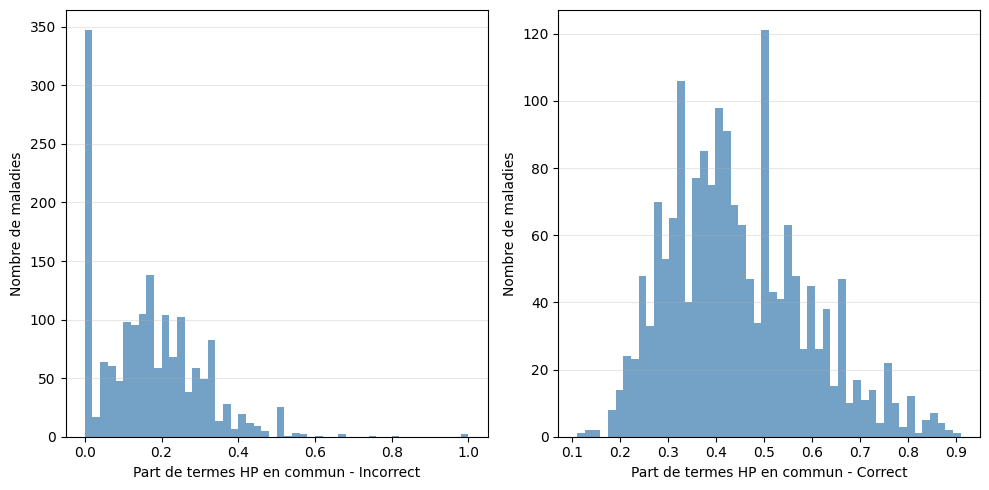

In [7]:
# Histplot part de termes en commun entre maladies omim et orpha
var1 = [len(paires_zero_dict[c]["commun"])/paires_zero_dict[c]["omim"]["count"] for c in paires_zero_dict.keys()]
var2 = [len(paires_correct_dict[c]["commun"])/paires_correct_dict[c]["omim"]["count"] for c in paires_correct_dict.keys()]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
sns.histplot(var1, bins=50, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de termes HP en commun - Incorrect")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(var2, bins=50, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de termes HP en commun - Correct")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
ancestors = {hp: get_ancestors0(G_hpo_work, hp) for hp in hpo_cols0}

def propagate_pivot(df, ancestors):
    hp_cols = [c for c in df.columns if c.startswith('HP:')]
    df_prop = df.copy()
    for hp in hp_cols:
        descendants = [d for d in hp_cols if hp in ancestors.get(d, set())]
        if descendants:
            df_prop[hp] = df[[hp] + descendants].max(axis=1)
    return df_prop

work_omim0_P = propagate_pivot(work_omim0, ancestors)
work_orpha0_P = propagate_pivot(work_orpha0, ancestors)

## Ajout d'une régularisation Laplacienne en utilisant les PPI

On considère que deux maladies sont similaires si leurs protéines interagissent ensemble.

In [16]:
def simi_ppi(df):
    n = df.shape[0]
    protein_to_idx = defaultdict(list)
    for i, row in df.iterrows():
        proteins = row['protein'] if isinstance(row['protein'], list) else [row['protein']]
        for p in proteins:
            if pd.notna(p):
                protein_to_idx[p].append(i)

    S = np.zeros((n, n))
    for i, row in df.iterrows():
        interactions = list(row['protein2'])
        for p in interactions:
            list_j = protein_to_idx.get(p)
            if list_j is not None :
                for j in list_j:
                    S[i, j]=1
                    S[j, i]=1
    return S

df1_omim0 = df1_omim[df1_omim['disease_id'].isin(work_omim0['database_id'])].reset_index()
df1_orpha0 = df1_orpha[df1_orpha['disease_id'].isin(work_orpha0['database_id'])].reset_index()

simi_source = simi_ppi(df1_omim0)
simi_target = simi_ppi(df1_orpha0)

Text(0.5, 1.0, 'Target')

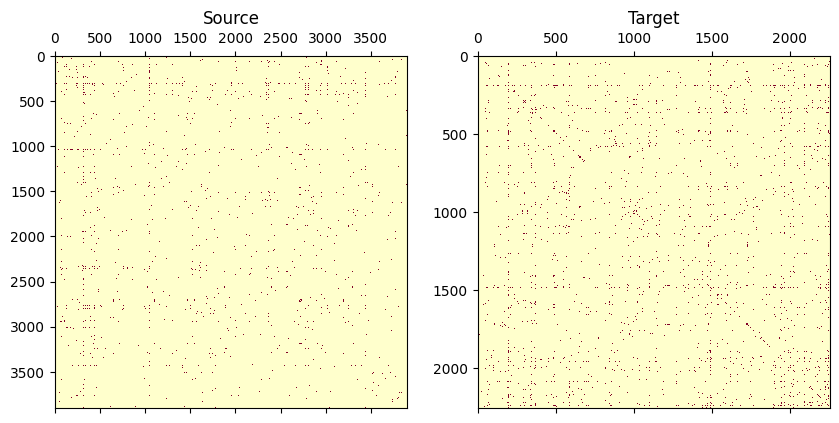

In [17]:
# Matrices de similarités : il faudrait ordonner les colonnes selon gene_gt_set ? 
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].matshow(simi_source, cmap="YlOrRd")
axes[0].set_title("Source")
axes[1].matshow(simi_target, cmap="YlOrRd")
axes[1].set_title("Target")

In [ ]:
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_array
n_comp1, labels1 = connected_components(csr_array(simi_source))
print(n_comp1)
n_comp2, labels2 = connected_components(csr_array(simi_target))
print(n_comp2)



254
106


In [ ]:
def gcg0(a,
    b,
    M,
    f,
    df,
    reg1,
    reg2,
    lp_solver,
    line_search,
    G0=None,
    numItermax=200,
    stopThr=1e-9,
    stopThr2=1e-9,
    **kwargs
    #log=False
    ):
    loop = 1
    #if log:
        #log = {"loss": []}
    if G0 is None:
        G = np.outer(a, b)
    else:
        G = np.copy(G0)
    if reg2 is None:
        def cost(G):
            return np.sum(M * G) + reg1 * f(G)
    else:
        def cost(G):
            return np.sum(M * G) + reg1 * f(G) + reg2 * np.sum(G * np.log(G))
    cost_G = cost(G)
    #if log:
        #log["loss"].append(cost_G)
    df_G = None
    it = 0
    while loop:
        it += 1
        old_cost_G = cost_G
        # problem linearization
        if df_G is None:
            df_G = df(G)
        Mi = M + reg1 * df_G
        if reg2 is not None:
            Mi = Mi + reg2 * (1 + nx.log(G))

        # solve linear program
        Gc, innerlog_ = lp_solver(a, b, Mi, **kwargs)
        # line search
        deltaG = Gc - G

        res_line_search = line_search(cost, G, deltaG, Mi, cost_G, df_G, **kwargs)
        if len(res_line_search) == 3:
            # the line-search does not allow to update the gradient
            alpha, fc, cost_G = res_line_search
            df_G = None
        else:
            # the line-search allows to update the gradient directly
            # e.g. while using quadratic losses as the gromov-wasserstein loss
            alpha, fc, cost_G, df_G = res_line_search

        G = G + alpha * deltaG

        # test convergence
        if it >= numItermax:
            loop = 0

        abs_delta_cost_G = abs(cost_G - old_cost_G)
        relative_delta_cost_G = (
            abs_delta_cost_G / abs(cost_G) if cost_G != 0.0 else np.nan
        )
        if relative_delta_cost_G < stopThr or abs_delta_cost_G < stopThr2:
            loop = 0

        #if log:
            #log["loss"].append(cost_G)
    return G

In [7]:
# Inspiré du code emd_laplace de la librairie POT
from ot import sinkhorn
from ot.optim import cg, gcg
from sklearn.neighbors import kneighbors_graph

def laplacian(x):
    r"""Compute Laplacian matrix"""
    L = np.diag(np.sum(x, axis=1)) - x
    return L

def otda(
    a, b, 
    df_source, df_target, 
    C, 
    Ss, St,
    epsilon,
    eta=1., 
    alpha=0.5, 
    reg="pos", 
    numItermax=1000,
    stopThr=1e-9,
    numInnerItermax=10_000,
    stopInnerThr=1e-9,
    log=False,
    verbose=False):

    n, m = C.shape
    if a is None:
        a = np.ones(n)/n
    if b is None:
        b = np.ones(m)/m

    xs = np.asarray(df_source, dtype=np.float64)
    xt = np.asarray(df_target, dtype=np.float64)
    print('xs', xs.shape)
    print('xt', xt.shape)
    if Ss is None or St is None :
        sim_param = 10
        Ss = kneighbors_graph(X=xs, n_neighbors=int(sim_param)).toarray()
        St = kneighbors_graph(X=xt, n_neighbors=int(sim_param)).toarray()
    sS = (Ss + Ss.T) / 2  
    sT = (St + St.T) / 2
    print('sS', sS.shape)
    print('sT', sT.shape)
    print("sS symétrique ?", np.allclose(sS, sS.T))
    print("sS valeurs négatives ?", (sS < 0).any())
    print("diag(sS) :", np.diag(sS)[:5])

    lS = laplacian(sS)
    lT = laplacian(sT)
    print('lS', lS.shape)
    print('lT', lT.shape)

    ls2 = lS + lS.T
    lt2 = lT + lT.T
    xt2 = np.dot(xt, xt.T)
    xs2 = np.dot(xs, xs.T)

    if reg == "disp":
        Cs = -eta * alpha / xs.shape[0] *(ls2 @ xs @ xt.T)
        Ct = -eta * (1 - alpha) / xt.shape[0] * (xs @ xt.T @ lt2)
        C = C + Cs + Ct

    def f(G):
        #GXt = G @ xt
        #term1 = np.einsum('ij,ij->', lS @ GXt, GXt)
        #term1 = np.trace(G.T.dot(ls2*0.5).dot(G))
        #GtXs = G.T @ xs
        #term2 = np.einsum('ij,ij->', lT @ GtXs, GtXs)
        #term2 = np.trace(G.dot(lt2*0.5).dot(G.T))
        #return alpha * term1 + (1 - alpha) * term2
        return alpha * np.trace(xt.T @ G.T @ lS @ G @ xt) + (1 - alpha) * np.trace(xs.T @ G @ lT @ G.T @ xs)

    def df(G):
        #return alpha * (ls2 @ G) + (1-alpha) * (G @ lt2)
        return alpha * (ls2 @ G @ xt2) + (1 - alpha) * (xs2 @ G @ lt2)

    assert (C >= 0).all(), "C contient des valeurs négatives !"
    G_emd = sinkhorn(a, b, C, reg=epsilon*np.mean(C))
    G_emd = G_emd/G_emd.sum()
    print("G0 nan:", np.isnan(G_emd).any())
    G0Xt = G_emd @ xt
    term1 = np.einsum('ij,ij->', lS @ G0Xt, G0Xt)
    G0tXs = G_emd.T @ xs
    term2 = np.einsum('ij,ij->', lT @ G0tXs, G0tXs)
    f_Gemd = alpha * term1 + (1 - alpha) * term2

    print("f(G_emd):", f_Gemd) 
    print("⟨G_emd, C⟩ :", np.sum(G_emd * C))
    print("ratio :", np.sum(G_emd * C) / f_Gemd)
    eta_calibrated = np.sum(G_emd*C)/f_Gemd
    return gcg(
        a,
        b,
        C,
        reg1=eta_calibrated*eta,
        reg2=epsilon,
        f=f,
        df=df,
        G0=None,
        numItermax=100, 
        numInnerItermax=100_000, 
        stopThr=1e-09, 
        stopThr2=1e-09, 
        verbose=True
    )

'''
    def lp_solver(a, b, M, **kwargs):
        return sinkhorn(a, b, M, reg=epsilon, 
                        numItermax=numInnerItermax,
                        stopThr=1e-9)

    G = a[:, None] * b[None, :]
    print('G', G.shape)
    for i in tqdm(range(numItermax)):
        M = C + eta * df(G)
        G_new = sinkhorn(a, b, M, reg=epsilon,
                         numItermax=numInnerItermax,
                         stopThr=1e-9)
        # Line search : pas optimal entre G et G_new
        delta = G_new - G
        G = G + 1.0 / (i + 2) * delta  # pas décroissant classique
        err = np.max(np.abs(delta))
        if verbose:
            print(f"iter {i}: err={err:.2e}")
        if err < stopThr:
            break

    return G
'''

'\n    def lp_solver(a, b, M, **kwargs):\n        return sinkhorn(a, b, M, reg=epsilon, \n                        numItermax=numInnerItermax,\n                        stopThr=1e-9)\n\n    G = a[:, None] * b[None, :]\n    print(\'G\', G.shape)\n    for i in tqdm(range(numItermax)):\n        M = C + eta * df(G)\n        G_new = sinkhorn(a, b, M, reg=epsilon,\n                         numItermax=numInnerItermax,\n                         stopThr=1e-9)\n        # Line search : pas optimal entre G et G_new\n        delta = G_new - G\n        G = G + 1.0 / (i + 2) * delta  # pas décroissant classique\n        err = np.max(np.abs(delta))\n        if verbose:\n            print(f"iter {i}: err={err:.2e}")\n        if err < stopThr:\n            break\n\n    return G\n'

In [5]:
work_omim00 = work_omim0[work_omim0['database_id'].isin(df1_omim0['disease_id'])].reset_index()
work_orpha00 = work_orpha0[work_orpha0['database_id'].isin(df1_orpha0['disease_id'])].reset_index()
work_cols = [c for c in work_omim00.columns if c.startswith("HP")]
gt_set00, valid_omim0, valid_orpha0 = f_ground_truth(work_omim00, work_orpha00, df_orpha_omim)

In [ ]:
# weights, _, _ = compute_information_content(gene_omim, G_hpo_work)
# weights = {t:-np.log(w) for t, w in weights.items()}
print("Computing cost...")
C = basic_cost_matrix(work_omim00, work_orpha00, 'hamming')
print("Done !")
#grid = np.linspace(0.01, 5, 100)
#epsilon = grid[1]*np.mean(C)
#print(f"Epsilon = {epsilon}")
for eta in [0.01, 0.1, 1., 100, 1000]:
    for epsilon in [0.01, 0.1, 1, 10.]:
        epsilon0 = epsilon * np.mean(C)
        print(f"Eta = {eta} et Epsilon = {epsilon}")
        ot_lapl = otda(
        None, None, 
        work_omim00[work_cols], work_orpha00[work_cols], 
        C, 
        simi_source, simi_target,
        epsilon, 
        eta, 
        alpha=0.5)
        print("transport computed")
        ranks_lapl, pairs_lapl = evaluate_transport(ot_lapl, gt_set00, C)

Computing cost...
Check : (3902, 2258)
Done !
Eta = 0.01 et Epsilon = 0.01
xs (3902, 11613)
xt (2258, 11613)
sS (3902, 3902)
sT (2258, 2258)
sS symétrique ? True
sS valeurs négatives ? False
diag(sS) : [0. 0. 0. 0. 0.]
lS (3902, 3902)
lT (2258, 2258)
G0 nan: False
f(G_emd): 0.15996153458572498
⟨G_emd, C⟩ : 0.0032239205096172554
ratio : 0.020154348468628402
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|1.162179e-03|0.000000e+00|0.000000e+00
    1|1.082647e-03|7.346092e-02|7.953225e-05
    2|1.072753e-03|9.222639e-03|9.893617e-06
    3|1.041173e-03|3.033108e-02|3.157992e-05
    4|1.032226e-03|8.668052e-03|8.947389e-06
    5|1.028299e-03|3.818577e-03|3.926641e-06
    6|1.027564e-03|7.153173e-04|7.350346e-07
    7|1.027490e-03|7.217067e-05|7.415466e-08
    8|1.027461e-03|2.828294e-05|2.905962e-08
    9|1.027444e-03|1.682211e-05|1.728377e-08
   10|1.027434e-03|9.488514e-06|9.748824e-09
   11|1.027429e-03|5.301648e-06|5.447065e-09
   12

KeyboardInterrupt: 

## Essai de Fused Gromov Wasserstein

In [6]:
def simi_ppi_crossed(df1, df2):
    n = df1.shape[0]
    m = df2.shape[0]
    protein_to_idx1 = defaultdict(list)
    protein_to_idx2 = defaultdict(list)
    for i, row in df1.iterrows():
        proteins = row['protein'] if isinstance(row['protein'], list) else [row['protein']]
        for p in proteins:
            if pd.notna(p):
                protein_to_idx1[p].append(i)
    for j, row in df2.iterrows():
        proteins = row['protein'] if isinstance(row['protein'], list) else [row['protein']]
        for p in proteins:
            if pd.notna(p):
                protein_to_idx2[p].append(j)
    S = np.zeros((n, m))

    for i, row in df1.iterrows():
        interactions = list(row['protein2'])
        for p in interactions:
            list_j = protein_to_idx2.get(p)
            if list_j is not None :
                for j in list_j:
                    S[i, j]=1
    # Check
    S_transp = np.zeros((m, n))
    for j, row in df2.iterrows():
        interactions = list(row['protein2'])
        for p in interactions:
            list_i = protein_to_idx1.get(p)
            if list_i is not None:
                for i in list_i:
                    S_transp[j, i]=1
                    if S_transp[j, i]!=S[i, j]:
                        print("p", p)
                        print("i", i)
                        print(row)
    assert np.array_equal(S_transp.T, S), "Les deux matrices doivent être égales"
    return S, S_transp

simi_omim_orpha, S_transp = simi_ppi_crossed(df1_omim0, df1_orpha0)

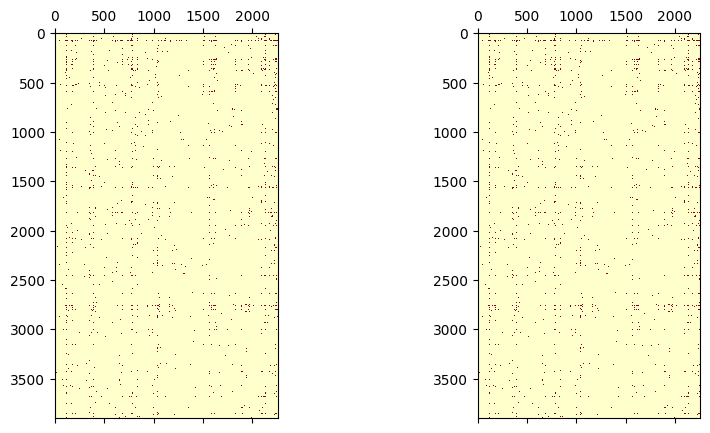

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].matshow(simi_omim_orpha, cmap="YlOrRd")
axes[1].matshow(S_transp.T, cmap="YlOrRd")

In [19]:
from ot import fused_gromov_wasserstein
from ot.gromov import entropic_fused_gromov_wasserstein

C1 = basic_cost_matrix(work_omim00, work_omim00, 'hamming')
C2 = basic_cost_matrix(work_orpha00, work_orpha00, 'hamming')

M = 1 - simi_omim_orpha
for eps in [0.1, 1., 10, 100]:
    ot_fgw = entropic_fused_gromov_wasserstein(M, C1, C2, epsilon=eps, alpha=0.9, loss_fun='kl_loss', max_iter=10e6, verbose=True)
    ranks, pairs = evaluate_transport(ot_fgw, gt_set00, None)

Check : (3902, 3902)
Check : (2258, 2258)
It.  |Err         
-------------------
    0|5.597811e-05|
   10|4.295927e-20|
Paires évaluées : 3898
Top-1 accuracy : 0.039 (151/3898)
Top-3 accuracy : 0.095 (372/3898)
Top-5 accuracy : 0.134 (521/3898)
 Rang moyen: 591.79
It.  |Err         
-------------------
    0|3.705267e-06|
   10|6.933592e-21|
Paires évaluées : 3898
Top-1 accuracy : 0.040 (156/3898)
Top-3 accuracy : 0.096 (374/3898)
Top-5 accuracy : 0.138 (538/3898)
 Rang moyen: 577.97
It.  |Err         
-------------------
    0|3.560501e-07|
   10|0.000000e+00|
Paires évaluées : 3898
Top-1 accuracy : 0.041 (158/3898)
Top-3 accuracy : 0.096 (375/3898)
Top-5 accuracy : 0.138 (538/3898)
 Rang moyen: 576.78
It.  |Err         
-------------------
    0|3.546404e-08|
   10|0.000000e+00|
Paires évaluées : 3898
Top-1 accuracy : 0.041 (158/3898)
Top-3 accuracy : 0.096 (376/3898)
Top-5 accuracy : 0.138 (538/3898)
 Rang moyen: 576.65
